In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("disaggregated_DLRM_trace.csv") # for 2025

print(df)


          instance_sn role app_name  cpu_request  cpu_limit  gpu_request  \
0          instance_0   HN    app_0           12         12            1   
1          instance_1   HN    app_0           12         12            1   
2          instance_2   HN    app_0           12         12            1   
3          instance_3   HN    app_0           12         12            1   
4          instance_4   HN    app_0           12         12            1   
...               ...  ...      ...          ...        ...          ...   
23866  instance_23866   CN    app_0           48         48            0   
23867  instance_23867   CN  app_100           64         64            0   
23868  instance_23868   CN   app_87           64         64            0   
23869  instance_23869   CN  app_126           96         96            0   
23870  instance_23870   CN   app_93           64         64            0   

       gpu_limit  rdma_request  rdma_limit  memory_request  memory_limit  \
0          

In [4]:
# Convert time columns to numbers 
df["creation_time"]  = pd.to_numeric(df["creation_time"], errors="coerce")
df["scheduled_time"] = pd.to_numeric(df["scheduled_time"], errors="coerce")
df["deletion_time"]  = pd.to_numeric(df["deletion_time"], errors="coerce")

# Keep only rows where creation_time and deletion_time exist since not each row has these paramaters
df = df.dropna(subset=["creation_time", "deletion_time"])

# Reset row indices after dropping rows
df = df.reset_index(drop=True)

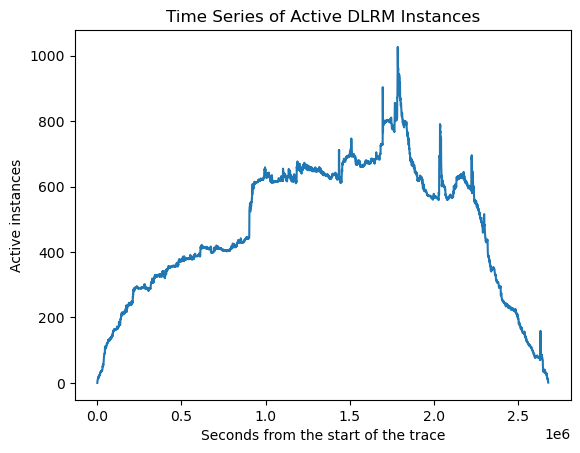

In [5]:

BIN_SIZE = 500 

# Find the overall time range
# Fin the earliest instance start time
t_start = int(df["creation_time"].min())
#Find the latest instance end time
t_end   = int(df["deletion_time"].max())

# Create time points
time_points = np.arange(t_start, t_end, BIN_SIZE)

active_counts = []

for t in time_points:
    # Select instances that are alive at time t
    is_active = (df["creation_time"] <= t) & (df["deletion_time"] > t)
    
    # Count how many are active
    count = is_active.sum()
    
    active_counts.append(count)

# Plot
plt.figure()
plt.plot(time_points, active_counts)
plt.xlabel("Seconds from the start of the trace")
plt.ylabel("Active instances")
plt.title("Time Series of Active DLRM Instances")
plt.show()

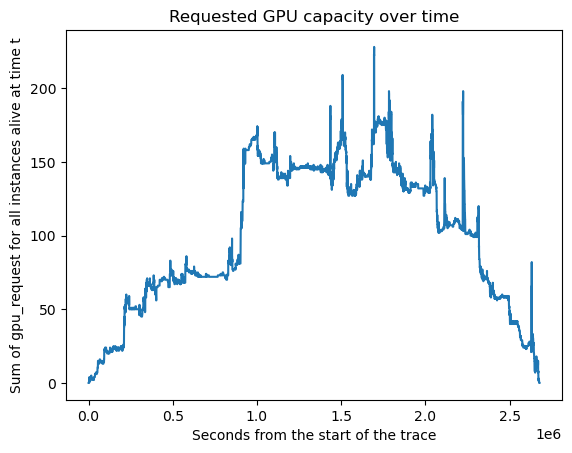

In [6]:
BIN_SIZE = 100

# Find the overall time range
# Fin the earliest instance start time
t_start = int(df["creation_time"].min())
#Find the latest instance end time.
t_end   = int(df["deletion_time"].max())

time_points = np.arange(t_start, t_end, BIN_SIZE)

gpu_demand = []

for t in time_points:
    is_active = (df["creation_time"] <= t) & (df["deletion_time"] > t)
    
    demand = df.loc[is_active, "gpu_request"].sum()
    
    gpu_demand.append(demand)

plt.figure()
plt.plot(time_points, gpu_demand)
plt.xlabel("Seconds from the start of the trace")
plt.ylabel("Sum of gpu_request for all instances alive at time t")
plt.title("Requested GPU capacity over time")
plt.show()

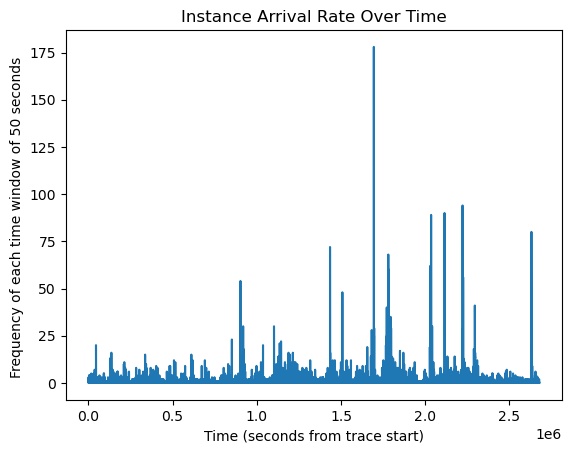

In [7]:

# plotting jsut "creation_time" to see how many instances were created during each time interval
BIN_SIZE = 50

t_start = int(df["creation_time"].min())
t_end   = int(df["deletion_time"].max())
time_bins = np.arange(t_start, t_end + BIN_SIZE, BIN_SIZE)

arrivals = []

for i in range(len(time_bins) - 1):
    t0 = time_bins[i]
    t1 = time_bins[i + 1]
    
    # Count instances created in [t0, t1)
    arrivals_now = df[(df["creation_time"] >= t0) & (df["creation_time"] < t1)]
    arrivals.append(len(arrivals_now))

# Plot with x-axis using the left edge of each bin
plt.figure()
plt.plot(time_bins[:-1], arrivals)
plt.xlabel("Time (seconds from trace start)")
#CHANGE THE Y AXIS
plt.ylabel("Frequency of each time window of 50 seconds ")
plt.title("Instance Arrival Rate Over Time")
plt.show()